<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day13-discussion-2.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 13, Segment 2 discussion — Does the same diffusion code work on a harder shape?

The book page's toy diffusion model recovers a ring. A ring is a single connected loop —
does the *exact same* code recover something with two separate clusters (two moons),
which has a much less trivial density?

torch.Size([4000, 2]) real mean/std: [1.4795992374420166, 0.7180134654045105] [2.570084810256958, 1.4990575313568115]


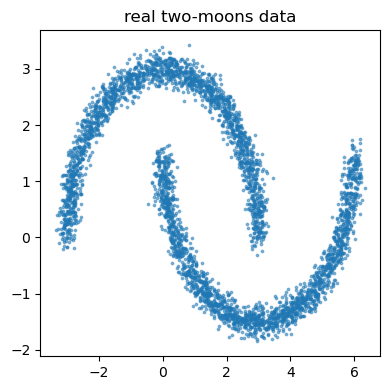

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def make_two_moons(n):
    n1 = n // 2
    t1 = torch.rand(n1) * np.pi
    x1 = torch.stack([torch.cos(t1), torch.sin(t1)], dim=1) * 3
    t2 = torch.rand(n - n1) * np.pi
    x2 = torch.stack([1 - torch.cos(t2), 1 - torch.sin(t2) - 0.5], dim=1) * 3
    x = torch.cat([x1, x2], dim=0)
    x += 0.15 * torch.randn_like(x)
    return x

X2d = make_two_moons(4000).to(device)
print(X2d.shape, 'real mean/std:', X2d.mean(0).tolist(), X2d.std(0).tolist())

fig, ax = plt.subplots(figsize=(4, 4))
xy = X2d.cpu().numpy()
ax.scatter(xy[:, 0], xy[:, 1], s=3, alpha=0.5)
ax.set_title('real two-moons data')
plt.tight_layout(); plt.savefig('day13-discussion2-real.png', dpi=110); plt.show()

## The same diffusion schedule and DenoiseNet as the book page, unchanged

In [2]:
T2 = 100
betas2 = torch.linspace(1e-4, 0.05, T2).to(device)
alphas2 = 1 - betas2
alpha_bars2 = torch.cumprod(alphas2, dim=0)

class DenoiseNet(nn.Module):
    def __init__(self, dim=2, hidden=128):
        super().__init__()
        self.time_embed = nn.Embedding(T2, hidden)
        self.net = nn.Sequential(nn.Linear(dim + hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, hidden), nn.ReLU(),
                                  nn.Linear(hidden, dim))

    def forward(self, x, t):
        te = self.time_embed(t)
        return self.net(torch.cat([x, te], dim=1))

dnet = DenoiseNet().to(device)
opt = torch.optim.Adam(dnet.parameters(), lr=1e-3)

for step in range(3000):
    idx = torch.randint(0, X2d.shape[0], (256,), device=device)
    x0 = X2d[idx]
    t = torch.randint(0, T2, (256,), device=device)
    noise = torch.randn_like(x0)
    ab = alpha_bars2[t].unsqueeze(1)
    xt = torch.sqrt(ab) * x0 + torch.sqrt(1 - ab) * noise
    pred = dnet(xt, t)
    loss = ((pred - noise) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()

print('final training loss:', loss.item())

final training loss: 0.7283743619918823


real mean/std:       [1.48  0.718] [2.57  1.499]
generated mean/std:  [0.826 0.82 ] [2.426 1.432]


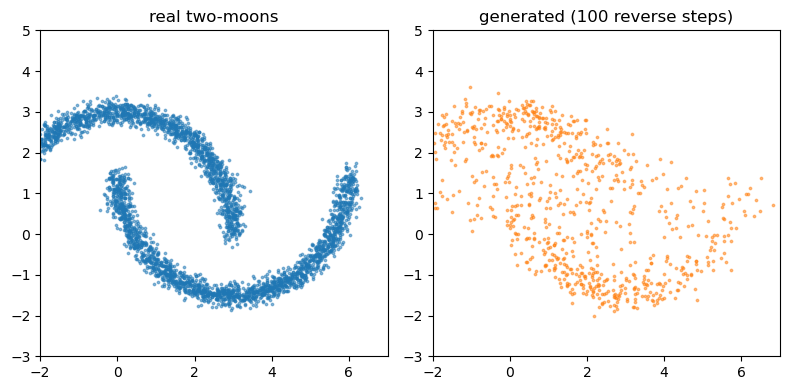

In [3]:
@torch.no_grad()
def reverse_sample(n=1000):
    x = torch.randn(n, 2, device=device)
    for t in reversed(range(T2)):
        tt = torch.full((n,), t, device=device, dtype=torch.long)
        pred_noise = dnet(x, tt)
        alpha, alpha_bar, beta = alphas2[t], alpha_bars2[t], betas2[t]
        noise = torch.randn_like(x) if t > 0 else torch.zeros_like(x)
        x = (1 / torch.sqrt(alpha)) * (x - (beta / torch.sqrt(1 - alpha_bar)) * pred_noise) + torch.sqrt(beta) * noise
    return x

generated = reverse_sample(1000).cpu().numpy()
real = X2d.cpu().numpy()
print('real mean/std:      ', real.mean(0).round(3), real.std(0).round(3))
print('generated mean/std: ', generated.mean(0).round(3), generated.std(0).round(3))

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].scatter(real[:, 0], real[:, 1], s=3, alpha=0.5); axes[0].set_title('real two-moons')
axes[1].scatter(generated[:, 0], generated[:, 1], s=3, alpha=0.5, color='C1'); axes[1].set_title('generated (100 reverse steps)')
for ax in axes: ax.set_xlim(-2, 7); ax.set_ylim(-3, 5)
plt.tight_layout()
plt.savefig('day13-discussion2-generated.png', dpi=110)
plt.show()

## Takeaway

Look carefully at the two scatter plots above: the generated points cover roughly
the same *region* as the real two-moons data (similar overall mean/std, printed
above), but they do **not** resolve the two separate crescent arms the way the ring
case cleanly recovered a ring — the generated cloud is much more blob-like, without
the clear gap between the two moons that the real data has. This is a genuine,
harder case, not a bug: a two-moons distribution has real internal structure (two
disconnected high-density regions with an empty gap between them) that a ring's
single connected loop doesn't, and the same architecture/training budget that
comfortably solved the easier shape visibly struggles here. Exactly the kind of
result worth reporting honestly in this project's own capstone-style write-ups:
"it didn't fully work, and here is a specific, measurable way it didn't" is a
better answer than claiming success that the plot doesn't support.